In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

RAW_PATH = "../data/raw/"
PROCESSED_PATH = "../data/processed/"
VISUAL_PATH = "../visualization/"

In [2]:
control = pd.read_csv(RAW_PATH + "control_group.csv", sep=";")
test = pd.read_csv(RAW_PATH + "test_group.csv", sep=";")

print("Control shape:", control.shape)
print("Test shape:", test.shape)

control.head()

Control shape: (30, 10)
Test shape: (30, 10)


,Campaign Name,Date,Spend [USD],# of Impressions,Reach,# of Website Clicks,# of Searches,# of View Content,# of Add to Cart,# of Purchase
0,Control Campaign,1.08.2019,2280,82702.0,56930.0,7016.0,2290.0,2159.0,1819.0,618.0
1,Control Campaign,2.08.2019,1757,121040.0,102513.0,8110.0,2033.0,1841.0,1219.0,511.0
2,Control Campaign,3.08.2019,2343,131711.0,110862.0,6508.0,1737.0,1549.0,1134.0,372.0
3,Control Campaign,4.08.2019,1940,72878.0,61235.0,3065.0,1042.0,982.0,1183.0,340.0
4,Control Campaign,5.08.2019,1835,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
print("Control columns:")
print(control.columns.tolist())

print("\nTest columns:")
print(test.columns.tolist())

Control columns:
['Campaign Name', 'Date', 'Spend [USD]', '# of Impressions', 'Reach', '# of Website Clicks', '# of Searches', '# of View Content', '# of Add to Cart', '# of Purchase']

Test columns:
['Campaign Name', 'Date', 'Spend [USD]', '# of Impressions', 'Reach', '# of Website Clicks', '# of Searches', '# of View Content', '# of Add to Cart', '# of Purchase']


In [4]:
# Add group label
control["Group"] = "Control"
test["Group"] = "Test"

# Combine both datasets
df = pd.concat([control, test], ignore_index=True)

print("Combined dataset shape:", df.shape)
df.head()

Combined dataset shape: (60, 11)


,Campaign Name,Date,Spend [USD],# of Impressions,Reach,# of Website Clicks,# of Searches,# of View Content,# of Add to Cart,# of Purchase,Group
0,Control Campaign,1.08.2019,2280,82702.0,56930.0,7016.0,2290.0,2159.0,1819.0,618.0,Control
1,Control Campaign,2.08.2019,1757,121040.0,102513.0,8110.0,2033.0,1841.0,1219.0,511.0,Control
2,Control Campaign,3.08.2019,2343,131711.0,110862.0,6508.0,1737.0,1549.0,1134.0,372.0,Control
3,Control Campaign,4.08.2019,1940,72878.0,61235.0,3065.0,1042.0,982.0,1183.0,340.0,Control
4,Control Campaign,5.08.2019,1835,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Control


In [5]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("#", "num")
    .str.replace("[", "", regex=False)
    .str.replace("]", "", regex=False)
)

df.columns.tolist()

['campaign_name',
 'date',
 'spend_usd',
 'num_of_impressions',
 'reach',
 'num_of_website_clicks',
 'num_of_searches',
 'num_of_view_content',
 'num_of_add_to_cart',
 'num_of_purchase',
 'group']

In [6]:
df = df.rename(columns={
    "spend_usd": "spend",
    "num_of_impressions": "impressions",
    "num_reach": "reach",
    "num_of_website_clicks": "website_clicks",
    "num_of_searches": "searches",
    "num_of_view_content": "view_content",
    "num_of_add_to_cart": "add_to_cart",
    "num_of_purchase": "purchase"
})

df.head()

,campaign_name,date,spend,impressions,reach,website_clicks,searches,view_content,add_to_cart,purchase,group
0,Control Campaign,1.08.2019,2280,82702.0,56930.0,7016.0,2290.0,2159.0,1819.0,618.0,Control
1,Control Campaign,2.08.2019,1757,121040.0,102513.0,8110.0,2033.0,1841.0,1219.0,511.0,Control
2,Control Campaign,3.08.2019,2343,131711.0,110862.0,6508.0,1737.0,1549.0,1134.0,372.0,Control
3,Control Campaign,4.08.2019,1940,72878.0,61235.0,3065.0,1042.0,982.0,1183.0,340.0,Control
4,Control Campaign,5.08.2019,1835,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Control


In [7]:
missing_values = pd.DataFrame({
    "column": df.columns,
    "missing_count": df.isnull().sum().values,
    "missing_percent": (df.isnull().sum().values / len(df)) * 100
})

missing_values[missing_values["missing_count"] > 0]

,column,missing_count,missing_percent
3,impressions,1,1.666667
4,reach,1,1.666667
5,website_clicks,1,1.666667
6,searches,1,1.666667
7,view_content,1,1.666667
8,add_to_cart,1,1.666667
9,purchase,1,1.666667


In [8]:
df["date"] = pd.to_datetime(df["date"], format="%d.%m.%Y", errors="coerce")

numeric_cols = [
    "spend",
    "impressions",
    "reach",
    "website_clicks",
    "searches",
    "view_content",
    "add_to_cart",
    "purchase"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df.dtypes

campaign_name                str
date              datetime64[us]
spend                      int64
impressions              float64
reach                    float64
website_clicks           float64
searches                 float64
view_content             float64
add_to_cart              float64
purchase                 float64
group                        str
dtype: object

In [9]:
for col in numeric_cols:
    df[col] = df.groupby("group")[col].transform(lambda x: x.fillna(x.median()))

df.isnull().sum()

campaign_name     0
date              0
spend             0
impressions       0
reach             0
website_clicks    0
searches          0
view_content      0
add_to_cart       0
purchase          0
group             0
dtype: int64

In [10]:
missing_values = pd.DataFrame({
    "column": df.columns,
    "missing_count": df.isnull().sum().values,
    "missing_percent": (df.isnull().sum().values / len(df)) * 100
})

missing_values[missing_values["missing_count"] > 0]

,column,missing_count,missing_percent


In [11]:
df["ctr"] = df["website_clicks"] / df["impressions"]
df["reach_rate"] = df["reach"] / df["impressions"]
df["search_rate"] = df["searches"] / df["website_clicks"]
df["view_content_rate"] = df["view_content"] / df["website_clicks"]
df["add_to_cart_rate"] = df["add_to_cart"] / df["website_clicks"]
df["purchase_conversion_rate"] = df["purchase"] / df["website_clicks"]
df["cart_to_purchase_rate"] = df["purchase"] / df["add_to_cart"]

df["cost_per_click"] = df["spend"] / df["website_clicks"]
df["cost_per_purchase"] = df["spend"] / df["purchase"]

df.replace([np.inf, -np.inf], np.nan, inplace=True)

df.head()

,campaign_name,date,spend,impressions,reach,website_clicks,searches,view_content,add_to_cart,purchase,group,ctr,reach_rate,search_rate,view_content_rate,add_to_cart_rate,purchase_conversion_rate,cart_to_purchase_rate,cost_per_click,cost_per_purchase
0,Control Campaign,2019-08-01,2280,82702.0,56930.0,7016.0,2290.0,2159.0,1819.0,618.0,Control,0.084835,0.688375,0.326397,0.307725,0.259265,0.088084,0.339747,0.324971,3.689320
1,Control Campaign,2019-08-02,1757,121040.0,102513.0,8110.0,2033.0,1841.0,1219.0,511.0,Control,0.067003,0.846935,0.250678,0.227004,0.150308,0.063009,0.419196,0.216646,3.438356
2,Control Campaign,2019-08-03,2343,131711.0,110862.0,6508.0,1737.0,1549.0,1134.0,372.0,Control,0.049411,0.841706,0.266902,0.238015,0.174247,0.057160,0.328042,0.360018,6.298387
3,Control Campaign,2019-08-04,1940,72878.0,61235.0,3065.0,1042.0,982.0,1183.0,340.0,Control,0.042057,0.840240,0.339967,0.320392,0.385971,0.110930,0.287405,0.632953,5.705882
4,Control Campaign,2019-08-05,1835,113430.0,91579.0,5224.0,2390.0,1984.0,1339.0,501.0,Control,0.046055,0.807361,0.457504,0.379786,0.256317,0.095904,0.374160,0.351263,3.662675


In [12]:
campaign_summary = df.groupby("group", as_index=False).agg({
    "spend": "sum",
    "impressions": "sum",
    "reach": "sum",
    "website_clicks": "sum",
    "searches": "sum",
    "view_content": "sum",
    "add_to_cart": "sum",
    "purchase": "sum"
})

campaign_summary["ctr"] = campaign_summary["website_clicks"] / campaign_summary["impressions"]
campaign_summary["purchase_conversion_rate"] = campaign_summary["purchase"] / campaign_summary["website_clicks"]
campaign_summary["cart_to_purchase_rate"] = campaign_summary["purchase"] / campaign_summary["add_to_cart"]
campaign_summary["cost_per_click"] = campaign_summary["spend"] / campaign_summary["website_clicks"]
campaign_summary["cost_per_purchase"] = campaign_summary["spend"] / campaign_summary["purchase"]

campaign_summary

,group,spend,impressions,reach,website_clicks,searches,view_content,add_to_cart,purchase,ctr,purchase_conversion_rate,cart_to_purchase_rate,cost_per_click,cost_per_purchase
0,Control,68653,3290663.0,2668082.0,159527.0,66808.0,58354.0,39039.0,15662.0,0.048479,0.098178,0.401189,0.430353,4.383412
1,Test,76892,2237544.0,1604747.0,180970.0,72569.0,55740.0,26446.0,15637.0,0.080879,0.086407,0.591280,0.424888,4.917312


In [13]:
control_summary = campaign_summary[campaign_summary["group"] == "Control"].iloc[0]
test_summary = campaign_summary[campaign_summary["group"] == "Test"].iloc[0]

uplift_summary = pd.DataFrame({
    "metric": [
        "CTR",
        "Purchase Conversion Rate",
        "Cart to Purchase Rate",
        "Cost per Click",
        "Cost per Purchase",
        "Total Purchase"
    ],
    "control": [
        control_summary["ctr"],
        control_summary["purchase_conversion_rate"],
        control_summary["cart_to_purchase_rate"],
        control_summary["cost_per_click"],
        control_summary["cost_per_purchase"],
        control_summary["purchase"]
    ],
    "test": [
        test_summary["ctr"],
        test_summary["purchase_conversion_rate"],
        test_summary["cart_to_purchase_rate"],
        test_summary["cost_per_click"],
        test_summary["cost_per_purchase"],
        test_summary["purchase"]
    ]
})

uplift_summary["uplift_percent"] = (
    (uplift_summary["test"] - uplift_summary["control"]) / uplift_summary["control"]
) * 100

uplift_summary

,metric,control,test,uplift_percent
0,CTR,0.048479,0.080879,66.833865
1,Purchase Conversion Rate,0.098178,0.086407,-11.989634
2,Cart to Purchase Rate,0.401189,0.591280,47.382157
3,Cost per Click,0.430353,0.424888,-1.269974
4,Cost per Purchase,4.383412,4.917312,12.179996
5,Total Purchase,15662.000000,15637.000000,-0.159622


In [14]:
from statsmodels.stats.proportion import proportions_ztest

control_clicks = control_summary["website_clicks"]
control_purchases = control_summary["purchase"]

test_clicks = test_summary["website_clicks"]
test_purchases = test_summary["purchase"]

count = np.array([test_purchases, control_purchases])
nobs = np.array([test_clicks, control_clicks])

z_stat, p_value = proportions_ztest(count, nobs, alternative="two-sided")

print("Control Conversion Rate:", control_purchases / control_clicks)
print("Test Conversion Rate:", test_purchases / test_clicks)
print("Z-statistic:", z_stat)
print("P-value:", p_value)

alpha = 0.05

if p_value < alpha:
    print("Result: Statistically significant difference between Control and Test campaign.")
else:
    print("Result: No statistically significant difference between Control and Test campaign.")

Control Conversion Rate: 0.09817773793777856
Test Conversion Rate: 0.08640658672708183
Z-statistic: -11.863488311496594
P-value: 1.8318117509100477e-32
Result: Statistically significant difference between Control and Test campaign.


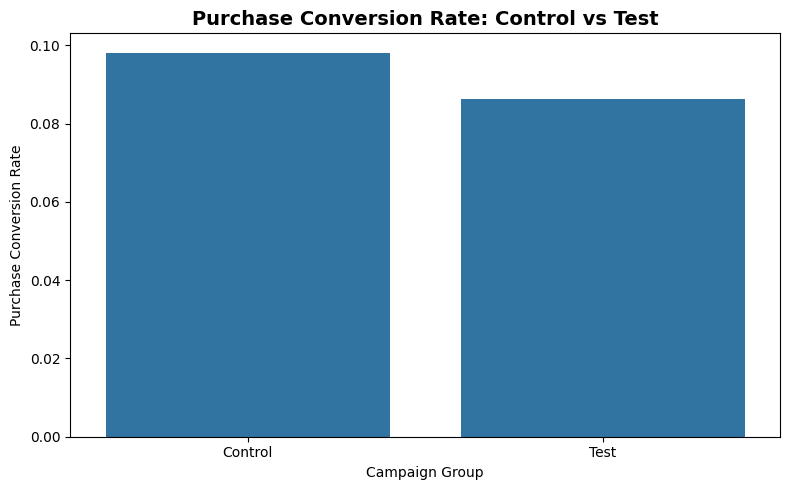

In [15]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=campaign_summary,
    x="group",
    y="purchase_conversion_rate"
)

plt.title("Purchase Conversion Rate: Control vs Test", fontsize=14, fontweight="bold")
plt.xlabel("Campaign Group")
plt.ylabel("Purchase Conversion Rate")
plt.tight_layout()

plt.savefig(VISUAL_PATH + "purchase_conversion_rate.png", dpi=300)
plt.show()

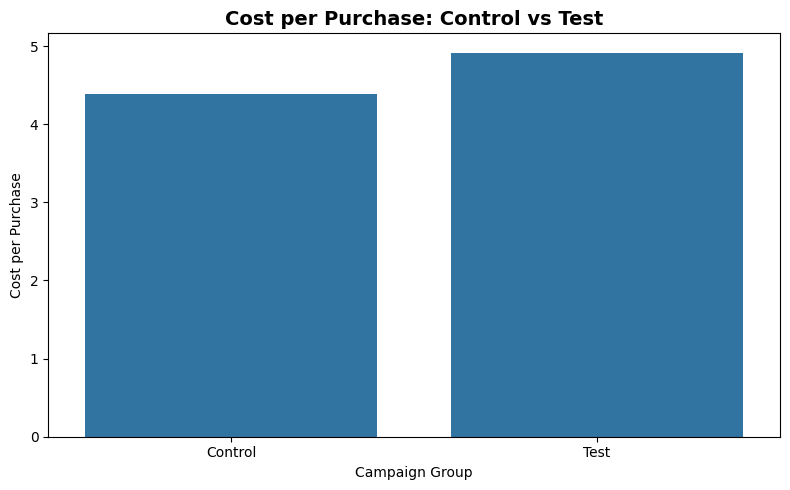

In [16]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=campaign_summary,
    x="group",
    y="cost_per_purchase"
)

plt.title("Cost per Purchase: Control vs Test", fontsize=14, fontweight="bold")
plt.xlabel("Campaign Group")
plt.ylabel("Cost per Purchase")
plt.tight_layout()

plt.savefig(VISUAL_PATH + "cost_per_purchase.png", dpi=300)
plt.show()

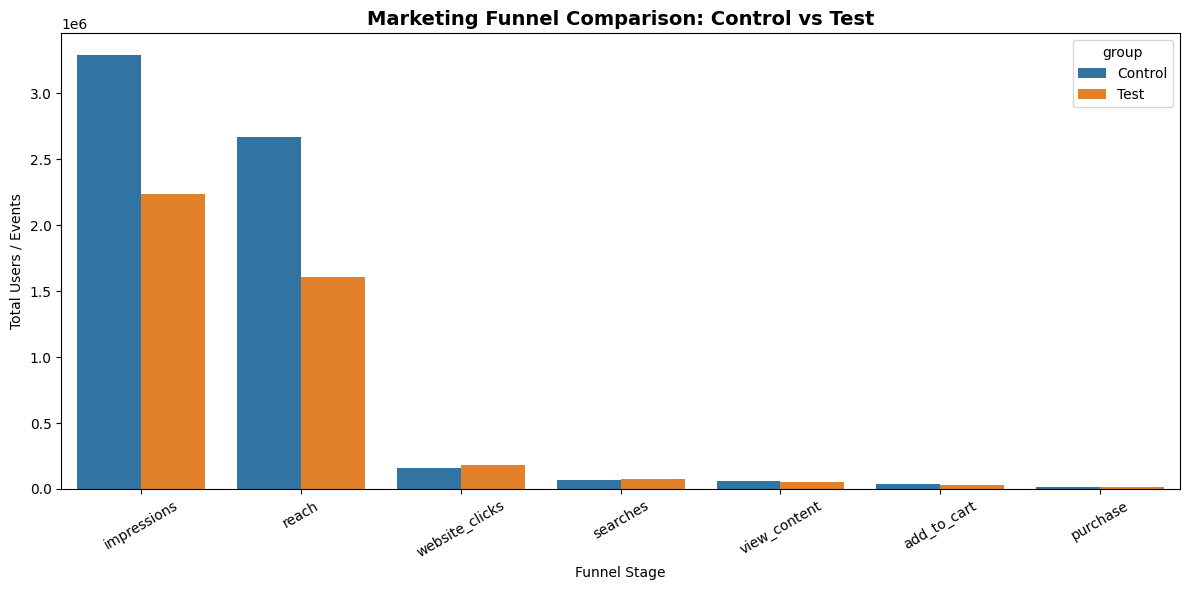

In [17]:
funnel_cols = [
    "impressions",
    "reach",
    "website_clicks",
    "searches",
    "view_content",
    "add_to_cart",
    "purchase"
]

funnel_summary = campaign_summary[["group"] + funnel_cols].copy()

funnel_melted = funnel_summary.melt(
    id_vars="group",
    value_vars=funnel_cols,
    var_name="funnel_stage",
    value_name="value"
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=funnel_melted,
    x="funnel_stage",
    y="value",
    hue="group"
)

plt.title("Marketing Funnel Comparison: Control vs Test", fontsize=14, fontweight="bold")
plt.xlabel("Funnel Stage")
plt.ylabel("Total Users / Events")
plt.xticks(rotation=30)
plt.tight_layout()

plt.savefig(VISUAL_PATH + "marketing_funnel_comparison.png", dpi=300)
plt.show()

In [18]:
df.to_csv(PROCESSED_PATH + "ab_testing_cleaned.csv", index=False)
campaign_summary.to_csv(PROCESSED_PATH + "campaign_summary.csv", index=False)
uplift_summary.to_csv(PROCESSED_PATH + "uplift_summary.csv", index=False)
funnel_melted.to_csv(PROCESSED_PATH + "funnel_summary.csv", index=False)

print("Processed files saved successfully!")
print("Cleaned data:", df.shape)
print("Campaign summary:", campaign_summary.shape)
print("Uplift summary:", uplift_summary.shape)
print("Funnel summary:", funnel_melted.shape)

Processed files saved successfully!
Cleaned data: (60, 20)
Campaign summary: (2, 14)
Uplift summary: (6, 4)
Funnel summary: (14, 3)


In [20]:
campaign_summary

,group,spend,impressions,reach,website_clicks,searches,view_content,add_to_cart,purchase,ctr,purchase_conversion_rate,cart_to_purchase_rate,cost_per_click,cost_per_purchase
0,Control,68653,3290663.0,2668082.0,159527.0,66808.0,58354.0,39039.0,15662.0,0.048479,0.098178,0.401189,0.430353,4.383412
1,Test,76892,2237544.0,1604747.0,180970.0,72569.0,55740.0,26446.0,15637.0,0.080879,0.086407,0.591280,0.424888,4.917312


In [22]:
uplift_summary

,metric,control,test,uplift_percent
0,CTR,0.048479,0.080879,66.833865
1,Purchase Conversion Rate,0.098178,0.086407,-11.989634
2,Cart to Purchase Rate,0.401189,0.591280,47.382157
3,Cost per Click,0.430353,0.424888,-1.269974
4,Cost per Purchase,4.383412,4.917312,12.179996
5,Total Purchase,15662.000000,15637.000000,-0.159622


In [24]:
ab_test_result = pd.DataFrame({
    "Metric": [
        "Control Conversion Rate",
        "Test Conversion Rate",
        "Z-statistic",
        "P-value",
        "Significance Level",
        "Conclusion"
    ],
    "Value": [
        control_purchases / control_clicks,
        test_purchases / test_clicks,
        z_stat,
        p_value,
        0.05,
        "Statistically significant difference. Control campaign performs better in purchase conversion."
    ]
})

ab_test_result

,Metric,Value
0,Control Conversion Rate,0.098178
1,Test Conversion Rate,0.086407
2,Z-statistic,-11.863488
3,P-value,0.0
4,Significance Level,0.05
5,Conclusion,Statistically significant difference. Control ...


In [25]:
ab_test_result.to_csv(PROCESSED_PATH + "ab_test_result.csv", index=False)

print("A/B test result saved successfully!")

A/B test result saved successfully!
